### Landsat Satellite Spectral Features Exploratory Data Analysis

In this notebook, EDA will be conducted on various features provided by the Landsat Satellite in our merged dataset. Those being `nir`, `green`, `swir16`, `swir22`, `ndmi`, and `mndwi`


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import primary_dataset, landsat_vis
import plotly.express as px
import folium
from branca.colormap import linear
from folium.plugins import MousePosition


#### Pulling the merged dataset

In [3]:
water_quality_df = pd.read_csv('data/wq.csv')
features = ['nir', 'green', 'swir16', 'swir22', 'ndmi', 'mndwi']
water_quality_df.head(10)

,province,country,latitude,longitude,sample date,nir,green,swir16,swir22,ndmi,...,total alkalinity,electrical conductance,dissolved reactive phosphorus,month,sample_year,pop_density_nn,distance_km_to_pd_cell,river_mouthORjunction,river_mouth,river_junction
0,Mpumalanga,South Africa,-26.861111,28.884722,2011-01-03,17658.5,9550.0,13746.5,10574.0,0.124566,...,74.720,162.9,163.0,2011-01-31,2011,5.049022,0.251555,0,0,0
1,Gauteng,South Africa,-26.450000,28.085833,2011-01-03,15210.0,10720.0,17974.0,14201.0,-0.083293,...,89.254,573.0,80.0,2011-01-31,2011,23.239988,0.419537,0,0,0
2,Free State,South Africa,-27.671111,27.236944,2011-01-03,14887.0,10943.0,13522.0,11403.0,0.048048,...,82.000,203.6,101.0,2011-01-31,2011,687.465759,0.069958,0,0,0
3,Free State,South Africa,-27.356667,27.286389,2011-01-03,16828.5,9502.5,12665.5,9643.0,0.141147,...,56.100,145.1,151.0,2011-01-31,2011,6.092811,0.232396,0,0,0
4,Free State,South Africa,-27.010111,26.698083,2011-01-04,12433.5,10433.5,9579.5,8531.5,0.129651,...,82.200,289.8,192.0,2011-01-31,2011,77.849716,0.466183,0,0,0
5,North West,South Africa,-25.127778,27.628889,2011-01-04,7814.0,5189.5,6664.0,5222.0,0.079431,...,125.000,438.0,163.0,2011-01-31,2011,3.473888,0.223439,0,0,0
6,North West,South Africa,-25.206390,27.558000,2011-01-04,14137.5,10466.5,10315.5,8536.0,0.156300,...,116.620,568.0,69.0,2011-01-31,2011,6.692756,0.383396,0,0,0
7,Limpopo,South Africa,-24.695140,27.409060,2011-01-04,15543.0,10647.0,11919.5,9642.5,0.131944,...,181.831,583.0,158.0,2011-01-31,2011,2.950710,0.253047,0,0,0
8,North West,South Africa,-26.984722,26.632278,2011-01-04,13683.0,10207.0,14011.5,11850.5,-0.011862,...,196.000,452.0,158.0,2011-01-31,2011,7.390572,0.529907,0,0,0
9,Free State,South Africa,-28.141944,26.417778,2011-01-04,14391.0,9840.0,13799.5,11265.0,0.020982,...,94.718,227.9,132.0,2011-01-31,2011,9.564678,0.481920,0,0,0


At a base level, let's take a look at some descriptive stastics of these columns

In [4]:
desc_df = pd.DataFrame(columns=["feature", "count", "mean", "std", "min", "25%", "median", "75%", "max"])

for feature in features:
    desc_df.loc[len(desc_df)] = ([feature] + list(water_quality_df[feature].describe()))
desc_df

,feature,count,mean,std,min,25%,median,75%,max
0,nir,9093.0,14076.357143,2781.388056,3992.000000,12989.000000,14183.000000,15306.000000,65535.000000
1,green,9093.0,9953.711096,2636.001818,4045.000000,9431.500000,9801.000000,10202.000000,65535.000000
2,swir16,9093.0,13602.848317,3155.115173,3672.500000,12100.500000,13704.250000,15196.000000,65535.000000
3,swir22,9093.0,11414.898686,2403.320108,3634.000000,10049.500000,11265.250000,12650.000000,31202.500000
4,ndmi,9093.0,0.021194,0.073279,-0.328293,-0.027309,0.021549,0.065376,0.567905
5,mndwi,9093.0,-0.148254,0.090995,-0.300487,-0.206646,-0.167901,-0.119244,0.590974


Here, it looks like `nir`, `swir16`, and `swir22` seem to share similar descriptive statistics. This makes sense since they deal with reflectance in the infrared wavelengths. This can open up the possibility of them being correlated with eachother, which would be detrimental to model training. Additionally, since `ndmi` and `mndwi` are based on other landsat features, it would be reasonable to check for collinearity.

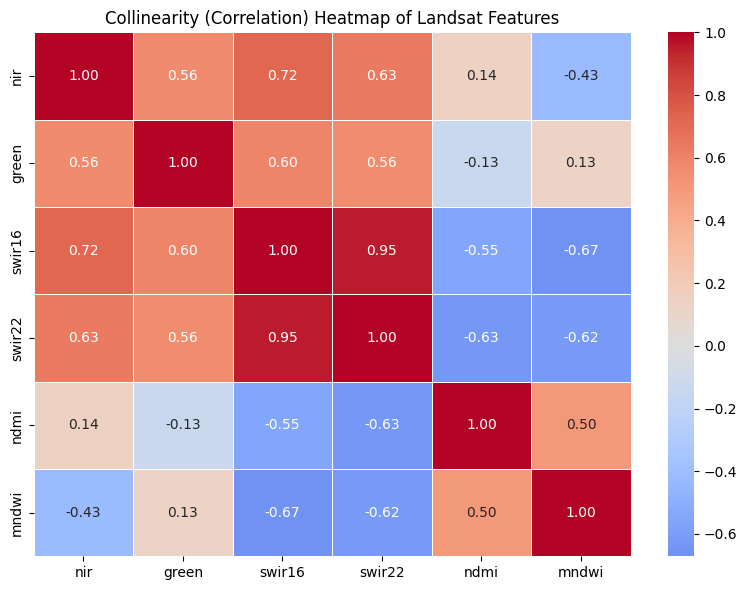

In [5]:
feature_df = water_quality_df[features]
collinearity_matrix = feature_df.corr()

# Set plot size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(
    collinearity_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Collinearity (Correlation) Heatmap of Landsat Features")
plt.tight_layout()
plt.show()

One important thing to note is the high correlation of 0.95 between `swir16` and `swir22`. This can be expected since they deal with very close wavelengths (1.6 and 2.2 micrometers). Because of the high correlation between the two, it would be reasonable (and much more efficient) to keep only one of these features to reduce redundancy. Let's keep `swir22`

Another important note is the lower correlations of `ndmi` and `mndwi` on the other landsat features. This indicates that even though they may be based on the other features, they carry nonlinear information that could be useful for model training.

Based on this analysis of collinearity, we can drop `swir16` and keep the other features

In [6]:
feature_df = feature_df.drop(["swir16"], axis=1)
feature_df

,nir,green,swir22,ndmi,mndwi
0,17658.5,9550.0,10574.0,0.124566,-0.180134
1,15210.0,10720.0,14201.0,-0.083293,-0.252805
2,14887.0,10943.0,11403.0,0.048048,-0.105416
3,16828.5,9502.5,9643.0,0.141147,-0.142683
4,12433.5,10433.5,8531.5,0.129651,0.042672
...,...,...,...,...,...
9088,15296.5,10043.0,14443.0,-0.034236,-0.239858
9089,15642.5,10294.5,14710.0,-0.042921,-0.246928
9090,14945.0,10732.0,16281.0,-0.100999,-0.260754
9091,14727.5,11051.0,15724.5,-0.111396,-0.250042


## Wavelength features (`nir`, `green`, `swir22`)

According to NASA, these Landsat features measure the brightness or reflectance of certain areas of Earth's surface towards the satellite. The reason why they have a max value of 65535 is due to their recent launch of Landsat 8, which encodes this brightness into a 16 bit integer (Max value of 16-bit integer is 65536). These features measure the brightness at various wavelengths in the EM spectrum:
- `green`: 530 - 590 nm
- `nir`: 850 - 880 nm
- `swir22`: 2100 - 2300 nm

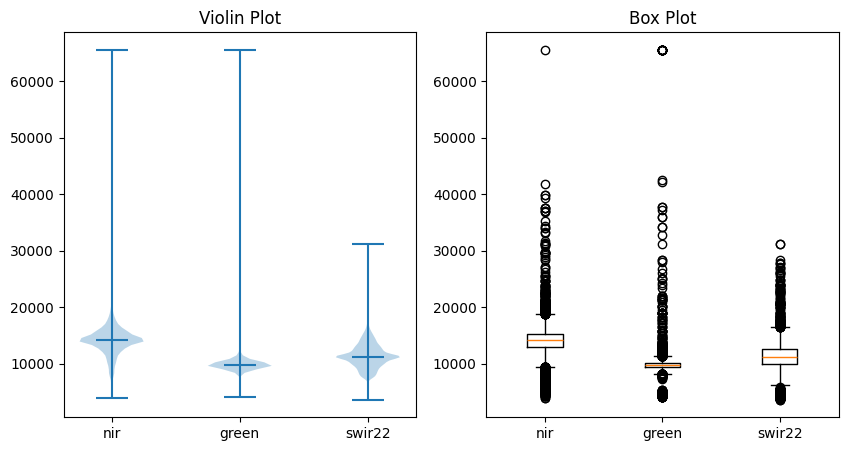

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
cols = ["nir", "green", "swir22"]

# Violin plot
axs[0].violinplot(feature_df[cols], showmedians=True)
axs[0].set_xticks([1, 2, 3])
axs[0].set_xticklabels(cols)
axs[0].set_title("Violin Plot")

# Box plot
axs[1].boxplot(feature_df[cols])
axs[1].set_xticks([1, 2, 3])
axs[1].set_xticklabels(cols)
axs[1].set_title("Box Plot")


plt.show()

#### Observation
Although the range is extensive for all of the wavelength reflectance features, it seems that the majority of samples fall within a much smaller range, with a large number of outliers. This is to be expected, as clouds, which can get in the way of satellite readings, have very high reflectance. Additionally, most of Earth's surfaces can reflect light in various ways, which can lead to a skewed distribution. To better understand the distribution of the wavelength reflectance features, let's try using a log scale.

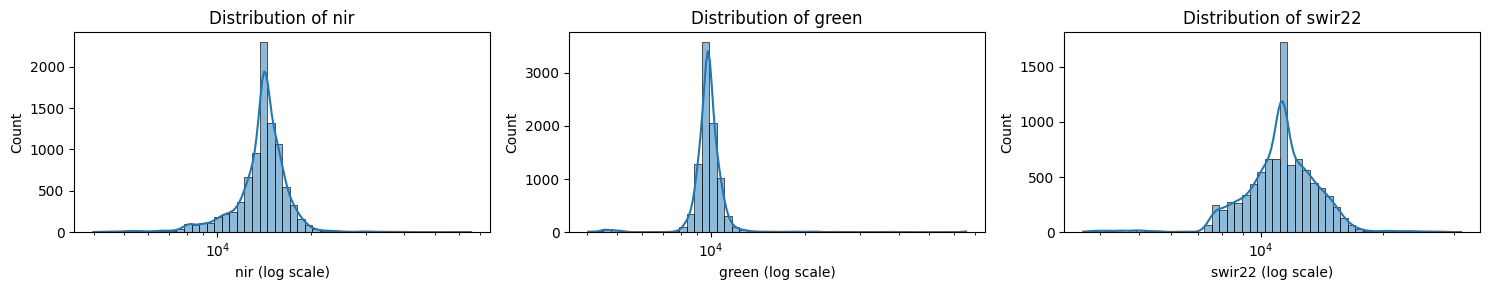

In [9]:
fig, axs = plt.subplots(1,3, figsize=(15, 3))

wl_features = ["nir", "green", "swir22"]

for i in range(len(wl_features)):
    feature = wl_features[i]
    sns.histplot(
        water_quality_df[feature],
        bins=50,
        kde=True,
        ax=axs[i],
        log_scale=True
    )

    axs[i].set_xlabel(f"{feature} (log scale)")
    axs[i].set_title(f"Distribution of {feature}")
    
plt.tight_layout()
plt.show()

#### Observation
All 3 of the wavelength reflectance features seem to have a unimodal distribution when viewed from a log-scale perspective. They also cluster tightly around a narrow range, indicating most samples having similar wavelength reflectances. There are also extreme readings that can explain the right-tail in all the wavelength features. Let's analyze them one by one in a spatial sense, averaged over the 5 years.

In [10]:
agg_dict = {
    'nir': 'mean',
    'green': 'mean',
    'swir22': 'mean',
    'mndwi': 'mean', # We will be analyzing this later
    'pop_density_nn': 'mean'
}

grouped_averages_df = water_quality_df.groupby(['latitude', 'longitude']).agg(agg_dict).reset_index()
print(f"{len(grouped_averages_df)} unique sample sites over 5 years.")
grouped_averages_df.head()

157 unique sample sites over 5 years.


,latitude,longitude,nir,green,swir22,mndwi,pop_density_nn
0,-34.405833,19.600556,15318.340909,9392.363636,10805.664773,-0.176482,3.317067
1,-34.329722,18.990278,12639.673077,9140.163462,10505.009615,-0.138843,0.763360
2,-34.250556,20.992500,12031.954545,8592.465909,9582.187500,-0.134179,3.858891
3,-34.092222,21.295278,17147.965116,9890.837209,12486.284884,-0.228195,58.138168
4,-34.075556,20.145556,15637.735849,10318.820755,13248.254717,-0.229577,0.533121


### 1) Near infrared reflectance: `nir`
##### a) Overview
This feature measures the reflectance of near-infrared wavelengths, typically 850 to 880 nanometers. This measurement is typically used to estimate the presence of vegetation, as it reflects a lot of near-infrared radiation. Water, however, absorbs most of it once NIR light hits it. Because of this, it is reasonable to say that lower values of NIR can be correlated with clearer water at the surface level, with high values suggesting the presence of vegeation and algal materials at the surface of the water.

Something also worth exploring is if population density can affect NIR, as urban activites can lead to possible vegetation and pollution coming into contact with nearby water, affecting its NIR. Plotted below is a spatial map of NIR across various sample sites. Samples that have a population density above the 75th percentile are also encircled in red.

##### b) Spatial distribution

In [10]:
landsat_vis.gen_map(grouped_averages_df, 'nir', log_plot=True)

##### c) Observation/Analysis
Spatially, it seems that samples took in coastal regions have a higher `log(nir)` than those taken more towards the inside of South Africa, indicated by the more lightly-colored dots. Additionally, it seems that out of the top 25% of samples with the highest population density (circled in red), the majority of them seem to have a higher `log(nir)` than the samples with less population density. The most prominent example of this is in the Western Cape/Cape Town area, where there is a large cluster of higher-population density areas containing one of the highest average NIR. This could indicate a possible correlation with population density, as highly populated areas with large amounts of urban activity could increase the amount of algal materials in water, affecting NIR. As a next step, this relationship could be explored further, as well as the relationship of `nir` with variables directly related to water quality such as `TA`, `EC`, and `DRP`

### 2) Green reflectance: `green`
##### a) Overview
This feature measures the reflectance of visible light particularly in wavelengths attributed with the color green which is 530 to 590 nanometers. This can be used to estimate the amount of dissolved organic matter in water, as they absorb green wavelengths. However, unlike `nir` which gets absorbed at the surface by water, wavelengths near the `green` band aren't as easily absorbed and are more sensitive to materials below the surface of water. In other words, `nir` can give insight to what's ON the water, while `green` can give insight to what's IN the water.

Similar to what we did for NIR, exploring a possible relationship with population density would be fruitful. We can follow a similar plotting method.

##### b) Spatial distribution

In [ ]:
landsat_vis.gen_map(grouped_averages_df, 'green', log_plot=True)

##### c) Observation/Analysis
Contrary to `nir`, it seems that in clusters of areas with high population density, the average `log(green)` reading seems to be lower than those with low population density, indicated by the darker dots. This could be explained by larger amounts of dissolved organic matter (DOM) in these areas, often impacted by sewage and wastewater. As a next step, it would be interesting to explore how different aspects about cities, such as industrial activites and transportation demographics.

### 3) Short-wave Infrared 2: `swir22`
##### a) Overview
This feature measures reflectance in the infrared band, specifically wavelengths ranging from 2100 - 2300 nanometers. This measurement is typically used for estimating the amount of suspended materials and sediment in water. Since water almost completely absorbs SWIR22 wavelengths, having a high SWIR22 value indicates a large presence of these particles. Unlike `nir`, which can estimates vegetation in water, `swir22` is used for the presence of minerals and inorganic material.

##### b) Spatial distribution

In [ ]:
landsat_vis.gen_map(grouped_averages_df, "swir22", log_plot=True)

##### c) Observation/Analysis

This is interesting because in the trends shown by `nir` and `green`, one would expect areas with higher population density to have a larger amount of foreign material in nearby water, resulting in a higher average `swir22` value. However, the opposite seems to be observed. We need to remember that `swir22` is mainly used for estimating the presence of sediments, which seem to be pretty low for these large cities. However, it seems that a potential issue with water in these large cities could be more biologically based, as the trends shown by `nir` and `green` show a high presence of vegetation and algal material within nearby water.

Overall, it seems that population density seems to have some correlation with these wavelength features. It would be interesting to explore further what kind of relationship each wavelength has with it as a next step.

## Normalized indices: `ndmi` and `mndwi`

These two are normalized indices (Ranging from -1 to 1) calculated from other landsat wavelength reflectance features. NDMI (Normalized difference moisture index), estimates the moisture content in nearby vegetation, and MNDWI (Modified normalized difference water index) is typically used to detect open water, with high values representing clear, open water, and low values representing unclear, turbid water. Since MNDWI appears to have a closer connection to water quality, let's examine that. 

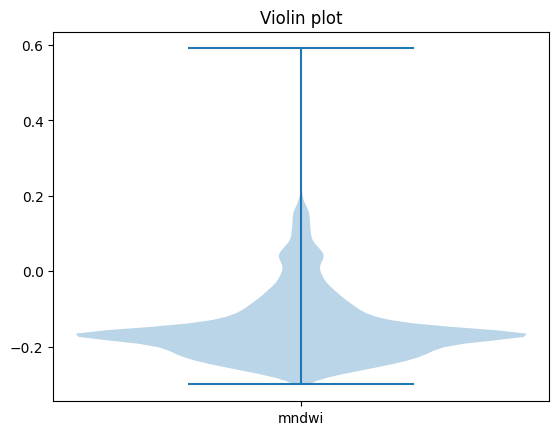

In [47]:

cols = ["mndwi"]
plt.violinplot(water_quality_df[cols])
plt.title("Violin plot")
plt.xticks([1], cols)
plt.show()

### Observation
Here, it seems like most MNDWI readings, indicating the presence of turbid water. This makes sense given the observations we found with the wavelength features, as we can infer that their high readings signify the presence of foreign material in water. Like before with our analysis on the wavelength features, it would be also useful to see how MNDWI is spatially distributed.

### Modified Normalized Difference Water Index: `mndwi`

In [11]:
landsat_vis.gen_map(grouped_averages_df, 'mndwi')